# Notebook 03 — Sistema multimodal con MongoDB Atlas + MiniLM + CLIP

Este notebook implementa un sistema multimodal usando **MongoDB Atlas Vector Search**. Permite trabajar con consultas:

- **texto → texto** usando MiniLM.
- **texto → imagen** usando CLIP.
- **imagen → imagen** usando CLIP.
- **imagen → texto** usando CLIP.
- Pipeline RAG multimodal opcional con un LLM compatible con OpenAI/Groq.

El notebook está diseñado para estudiantes: usa nombres de base y colecciones configurables, imágenes sintéticas locales para evitar problemas con URLs externas y funciones robustas para evitar errores comunes de CLIP.

## 1. Instalación de dependencias

Este bloque instala las librerías necesarias para:

- conectarse a MongoDB Atlas (`pymongo`),
- generar embeddings de texto (`sentence-transformers`),
- generar embeddings multimodales con CLIP (`transformers`, `torch`, `pillow`),
- integrar un LLM (`openai`),
- visualizar resultados (`pandas`, `matplotlib`).

In [ ]:
!pip -q install pymongo[srv] sentence-transformers transformers pillow openai pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 29.6 MB/s eta 0:00:00


## 2. Imports generales

Se importan las librerías que se usarán durante todo el notebook. También se habilitan utilidades para manejar imágenes, fechas, rutas locales y visualización.

In [ ]:
import os
import json
import math
import getpass
from pathlib import Path
from typing import List, Dict, Optional, Any
from datetime import datetime, UTC

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

import torch
from sentence_transformers import SentenceTransformer
from transformers import CLIPModel, CLIPProcessor

from pymongo import MongoClient, ASCENDING
from pymongo.errors import OperationFailure, ServerSelectionTimeoutError
from openai import OpenAI

pd.set_option("display.max_colwidth", 120)

## 3. Configuración general

Esta es la única celda que los estudiantes deberían modificar.

- `DB_NAME`: nombre de la base de datos.
- `COLLECTION_DOCUMENTS`: colección para documentos completos.
- `COLLECTION_CHUNKS`: colección para unidades recuperables: chunks de texto e imágenes.
- `COLLECTION_QUERIES`: colección para registrar consultas.
- `COLLECTION_ANSWERS`: colección para guardar respuestas generadas.

Los índices vectoriales deben crearse en Atlas sobre la colección de chunks.

In [ ]:
MONGODB_URI = getpass.getpass("MONGODB_URI de MongoDB Atlas: ").strip()

DB_NAME = input("Nombre de la base de datos [ejemplo_multimodal]: ").strip() or "ejemplo_multimodal"
COLLECTION_DOCUMENTS = input("Colección de documentos [multimodal_documents]: ").strip() or "multimodal_documents"
COLLECTION_CHUNKS = input("Colección de chunks/objetos recuperables [multimodal_chunks]: ").strip() or "multimodal_chunks"
COLLECTION_QUERIES = input("Colección de consultas [multimodal_queries]: ").strip() or "multimodal_queries"
COLLECTION_ANSWERS = input("Colección de respuestas [multimodal_answers]: ").strip() or "multimodal_answers"

# Nombres sugeridos para índices vectoriales de Atlas Search
INDEX_TEXT_MINILM = "idx_text_minilm_384"
INDEX_CLIP_TEXT = "idx_clip_text_512"
INDEX_CLIP_IMAGE = "idx_clip_image_512"

# Parámetro de búsqueda: si Atlas Vector Search falla por índice no creado, se usará búsqueda exacta local para demo.
USE_FALLBACK_LOCAL_SEARCH = True

print("Configuración cargada.")

MONGODB_URI de MongoDB Atlas: ··········
Nombre de la base de datos [ejemplo_multimodal]: 
Colección de documentos [multimodal_documents]: 
Colección de chunks/objetos recuperables [multimodal_chunks]: 
Colección de consultas [multimodal_queries]: 
Colección de respuestas [multimodal_answers]: 
Configuración cargada.


## 4. Conexión a MongoDB Atlas

Este bloque crea el cliente de MongoDB y selecciona las colecciones configuradas. La lógica queda genérica: no depende de nombres específicos usados en clase por el profesor ni de un cluster particular.

In [ ]:
client = MongoClient(MONGODB_URI, serverSelectionTimeoutMS=15000)

try:
    client.admin.command("ping")
    print("Conexión exitosa a MongoDB Atlas.")
except ServerSelectionTimeoutError as e:
    raise RuntimeError("No fue posible conectarse a MongoDB Atlas. Revisa MONGODB_URI, IP whitelist y credenciales.") from e

db = client[DB_NAME]
documents_collection = db[COLLECTION_DOCUMENTS]
chunks_collection = db[COLLECTION_CHUNKS]
queries_collection = db[COLLECTION_QUERIES]
answers_collection = db[COLLECTION_ANSWERS]

print("Base activa:", DB_NAME)
print("Colecciones actuales:", db.list_collection_names())

Conexión exitosa a MongoDB Atlas.
Base activa: ejemplo_multimodal
Colecciones actuales: []


## 5. Carga de modelos

Se cargan dos modelos:

- **MiniLM** para búsqueda texto → texto. Produce embeddings de 384 dimensiones.
- **CLIP** para búsqueda cruzada texto ↔ imagen. Produce embeddings de 512 dimensiones.

MiniLM es eficiente para similitud textual. CLIP permite comparar texto e imágenes en un mismo espacio semántico.

In [ ]:
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

print("MiniLM y CLIP cargados.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

MiniLM y CLIP cargados.


## 6. Funciones de embeddings

Estas funciones convierten texto e imágenes en vectores.

Se usan rutas explícitas del modelo CLIP (`text_model` y `vision_model`) para evitar errores frecuentes donde `get_text_features` o `get_image_features` devuelven objetos intermedios en lugar de tensores.

In [ ]:
def normalize_vector(vec: np.ndarray) -> List[float]:
    vec = np.asarray(vec, dtype=np.float32)
    norm = np.linalg.norm(vec)
    if norm == 0:
        return vec.tolist()
    return (vec / norm).tolist()


def embed_text_minilm(text: str) -> List[float]:
    """Embedding textual con MiniLM. Dimensión: 384."""
    vec = embedding_model.encode(text)
    return np.asarray(vec, dtype=np.float32).tolist()


def embed_text_clip(text: str) -> List[float]:
    """
    Embedding textual con CLIP. Dimensión: 512.
    Sirve para comparar texto contra imágenes o contra textos codificados con CLIP.
    """
    inputs = clip_processor(
        text=[text],
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    with torch.no_grad():
        outputs = clip_model.text_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs.get("attention_mask", None)
        )

        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            pooled = outputs.pooler_output
        else:
            pooled = outputs.last_hidden_state[:, 0, :]

        text_features = clip_model.text_projection(pooled)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    return text_features[0].cpu().numpy().astype(np.float32).tolist()


def embed_image_clip(image: Image.Image) -> List[float]:
    """
    Embedding visual con CLIP. Dimensión: 512.
    Sirve para comparar imagen contra imagen y imagen contra texto CLIP.
    """
    image = image.convert("RGB")
    inputs = clip_processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = clip_model.vision_model(pixel_values=inputs["pixel_values"])

        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            pooled = outputs.pooler_output
        else:
            pooled = outputs.last_hidden_state[:, 0, :]

        image_features = clip_model.visual_projection(pooled)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    return image_features[0].cpu().numpy().astype(np.float32).tolist()


# Validación rápida de dimensiones
print("MiniLM:", len(embed_text_minilm("prueba")))
print("CLIP texto:", len(embed_text_clip("prueba")))

MiniLM: 384
CLIP texto: 512


## 7. Datos demo sin dependencia de internet

Para evitar errores de descarga externa, se generan imágenes sintéticas locales con PIL. Esto hace que el notebook sea estable para clase y no dependa de URLs públicas.

In [ ]:
DEMO_DIR = Path("/content/demo_multimodal_images")
DEMO_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_DOCS = [
    {
        "doc_id": "DOC001",
        "titulo": "Agricultura de precisión y sensores",
        "idioma": "es",
        "fuente": "demo",
        "contenido_texto": "La agricultura de precisión utiliza sensores, datos satelitales e inteligencia artificial para monitorear cultivos, optimizar el riego y reducir el uso de fertilizantes."
    },
    {
        "doc_id": "DOC002",
        "titulo": "Turismo rural sostenible",
        "idioma": "es",
        "fuente": "demo",
        "contenido_texto": "El turismo rural sostenible promueve experiencias culturales, paisajes naturales y participación comunitaria, reduciendo impactos ambientales y fortaleciendo economías locales."
    },
    {
        "doc_id": "DOC003",
        "titulo": "Energía solar en comunidades",
        "idioma": "es",
        "fuente": "demo",
        "contenido_texto": "La energía solar permite a comunidades rurales acceder a electricidad limpia mediante paneles fotovoltaicos, almacenamiento en baterías y sistemas de monitoreo energético."
    }
]

SAMPLE_IMAGES = [
    {
        "img_id": "IMG001",
        "doc_id": "DOC001",
        "filename": "agricultura_sensores.png",
        "descripcion": "Ilustración sintética de un campo agrícola con sensores y monitoreo tecnológico.",
        "etiquetas": ["agricultura", "sensores", "campo", "tecnologia"],
        "bg": (150, 210, 140),
        "fg": (30, 90, 30),
        "label": "Agricultura + sensores"
    },
    {
        "img_id": "IMG002",
        "doc_id": "DOC002",
        "filename": "turismo_rural.png",
        "descripcion": "Ilustración sintética de turismo rural con montañas, camino y paisaje natural.",
        "etiquetas": ["turismo", "rural", "paisaje", "naturaleza"],
        "bg": (160, 200, 240),
        "fg": (80, 80, 40),
        "label": "Turismo rural"
    },
    {
        "img_id": "IMG003",
        "doc_id": "DOC003",
        "filename": "energia_solar.png",
        "descripcion": "Ilustración sintética de paneles solares y energía limpia en comunidad rural.",
        "etiquetas": ["energia", "solar", "paneles", "comunidad"],
        "bg": (250, 220, 130),
        "fg": (60, 70, 90),
        "label": "Energía solar"
    }
]


def create_synthetic_image(path: Path, bg, fg, label: str):
    img = Image.new("RGB", (640, 360), color=bg)
    draw = ImageDraw.Draw(img)
    # Elementos gráficos simples para que CLIP tenga señales visuales distintas
    draw.rectangle([40, 220, 600, 330], fill=fg)
    draw.ellipse([460, 35, 580, 155], fill=(255, 235, 80))
    draw.rectangle([90, 120, 150, 210], outline=(255, 255, 255), width=5)
    draw.line([70, 300, 570, 240], fill=(255, 255, 255), width=4)
    draw.text((40, 30), label, fill=(0, 0, 0))
    img.save(path)
    return path

for item in SAMPLE_IMAGES:
    local_path = DEMO_DIR / item["filename"]
    create_synthetic_image(local_path, item["bg"], item["fg"], item["label"])
    item["local_path"] = str(local_path)

print("Imágenes demo creadas en:", DEMO_DIR)
for item in SAMPLE_IMAGES:
    print(item["img_id"], item["local_path"])

Imágenes demo creadas en: /content/demo_multimodal_images
IMG001 /content/demo_multimodal_images/agricultura_sensores.png
IMG002 /content/demo_multimodal_images/turismo_rural.png
IMG003 /content/demo_multimodal_images/energia_solar.png


## 8. Visualización rápida de imágenes demo

Este bloque permite verificar visualmente las imágenes sintéticas antes de generar embeddings.

IMG001 - Ilustración sintética de un campo agrícola con sensores y monitoreo tecnológico.


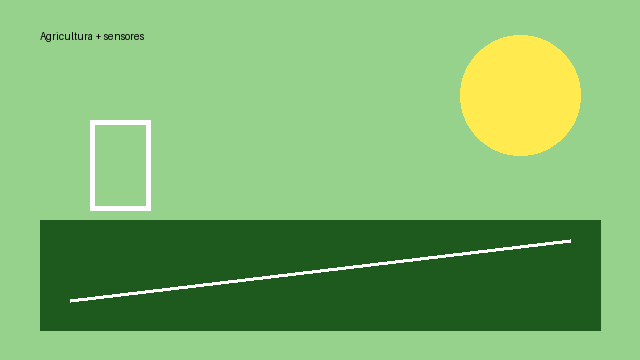

IMG002 - Ilustración sintética de turismo rural con montañas, camino y paisaje natural.


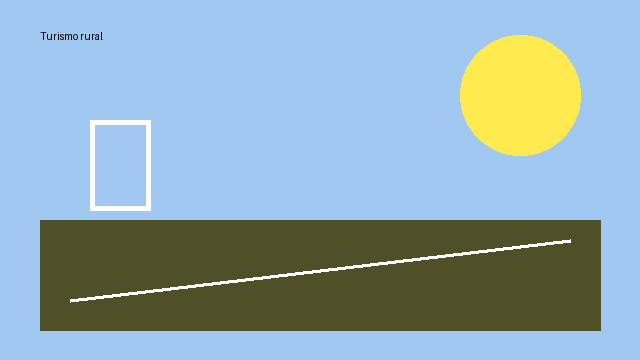

IMG003 - Ilustración sintética de paneles solares y energía limpia en comunidad rural.


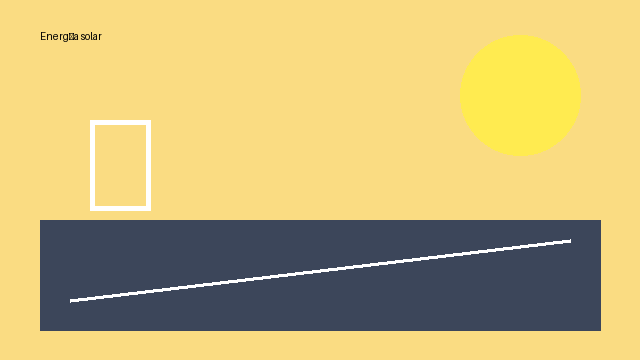

In [ ]:
for item in SAMPLE_IMAGES:
    print(item["img_id"], "-", item["descripcion"])
    display(Image.open(item["local_path"]).convert("RGB"))

## 9. Carga de datos multimodales en MongoDB Atlas

Este bloque inserta o actualiza:

- documentos completos en `documents_collection`,
- chunks de texto en `chunks_collection`,
- objetos de imagen en `chunks_collection`.

La colección de chunks es la colección recuperable: allí están los embeddings que usarán las búsquedas vectoriales.

In [ ]:
def upsert_multimodal_demo_data(sample_docs: List[Dict], sample_images: List[Dict]):
    """
    Inserta o actualiza datos demo multimodales.
    Usa variables genéricas:
    - documents_collection
    - chunks_collection
    """
    for doc in sample_docs:
        documents_collection.update_one(
            {"doc_id": doc["doc_id"]},
            {"$set": {
                "doc_id": doc["doc_id"],
                "titulo": doc["titulo"],
                "idioma": doc["idioma"],
                "fuente": doc["fuente"],
                "contenido_texto": doc["contenido_texto"],
                "created_at": datetime.now(UTC)
            }},
            upsert=True
        )

        chunks_collection.update_one(
            {"type": "text", "doc_id": doc["doc_id"], "chunk_id": 1},
            {"$set": {
                "type": "text",
                "doc_id": doc["doc_id"],
                "chunk_id": 1,
                "titulo": doc["titulo"],
                "idioma": doc["idioma"],
                "fuente": doc["fuente"],
                "contenido_texto": doc["contenido_texto"],
                "embedding_text": embed_text_minilm(doc["contenido_texto"]),       # 384 dims
                "embedding_clip_text": embed_text_clip(doc["contenido_texto"]),    # 512 dims
                "created_at": datetime.now(UTC)
            }},
            upsert=True
        )

    for img in sample_images:
        pil_img = Image.open(img["local_path"]).convert("RGB")
        chunks_collection.update_one(
            {"type": "image", "img_id": img["img_id"]},
            {"$set": {
                "type": "image",
                "img_id": img["img_id"],
                "doc_id": img["doc_id"],
                "local_path": img["local_path"],
                "descripcion": img["descripcion"],
                "etiquetas": img["etiquetas"],
                "embedding_image": embed_image_clip(pil_img),                      # 512 dims
                "created_at": datetime.now(UTC)
            }},
            upsert=True
        )

    print("Carga multimodal finalizada.")


upsert_multimodal_demo_data(SAMPLE_DOCS, SAMPLE_IMAGES)
print("Documentos:", documents_collection.count_documents({}))
print("Chunks/objetos multimodales:", chunks_collection.count_documents({}))

Carga multimodal finalizada.
Documentos: 3
Chunks/objetos multimodales: 6


## 10. Índices normales y definiciones de índices vectoriales

MongoDB Atlas Vector Search requiere índices vectoriales creados en Atlas. Este bloque:

1. crea índices normales útiles para filtros,
2. muestra las definiciones JSON que los estudiantes deben crear en Atlas Search.

> Nota: en algunos entornos se pueden crear índices Search desde PyMongo, pero para docencia es más claro dejar las definiciones listas para copiar en Atlas.

In [ ]:
from pymongo import ASCENDING

# ============================================================
# ÍNDICES NORMALES
# ============================================================

# Índices no únicos para búsqueda y filtros
chunks_collection.create_index([("type", ASCENDING)])
chunks_collection.create_index([("doc_id", ASCENDING)])
chunks_collection.create_index([("img_id", ASCENDING)])

# Índice único SOLO para documentos que realmente tengan doc_id tipo string
# Evita fallar con documentos viejos o vacíos donde doc_id es null.
documents_collection.create_index(
    [("doc_id", ASCENDING)],
    unique=True,
    partialFilterExpression={"doc_id": {"$type": "string"}}
)

print("Índices normales creados o verificados correctamente.")

Índices normales creados o verificados correctamente.


## 11. Funciones de búsqueda vectorial

Estas funciones implementan cuatro rutas:

1. **texto → texto**: MiniLM contra `embedding_text`.
2. **texto → imagen**: CLIP texto contra `embedding_image`.
3. **imagen → imagen**: CLIP imagen contra `embedding_image`.
4. **imagen → texto**: CLIP imagen contra `embedding_clip_text`.

Si el índice de Atlas Vector Search todavía no existe, se usa una búsqueda local exacta como respaldo para que el laboratorio pueda continuar con pocos datos demo.

In [ ]:
def cosine_similarity(a: List[float], b: List[float]) -> float:
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)


def local_vector_search(vector: List[float], field: str, filter_query: Dict[str, Any], top_k: int) -> pd.DataFrame:
    projection = {
        "_id": 0,
        "embedding_text": 0,
        "embedding_clip_text": 0,
        "embedding_image": 0
    }
    docs = list(chunks_collection.find(filter_query, projection))
    scored = []
    # Necesitamos recuperar el vector del campo solicitado, por eso se hace una segunda consulta ligera por documento.
    full_docs = list(chunks_collection.find(filter_query, {"_id": 0}))
    for doc in full_docs:
        if field not in doc:
            continue
        score = cosine_similarity(vector, doc[field])
        doc_clean = {k: v for k, v in doc.items() if not k.startswith("embedding_")}
        doc_clean["score"] = score
        scored.append(doc_clean)
    scored.sort(key=lambda x: x["score"], reverse=True)
    return pd.DataFrame(scored[:top_k])


def atlas_vector_search(vector: List[float], index_name: str, path: str, filter_query: Dict[str, Any], top_k: int) -> pd.DataFrame:
    pipeline = [
        {
            "$vectorSearch": {
                "index": index_name,
                "path": path,
                "queryVector": vector,
                "numCandidates": max(50, top_k * 10),
                "limit": top_k,
                "filter": filter_query
            }
        },
        {
            "$project": {
                "_id": 0,
                "embedding_text": 0,
                "embedding_clip_text": 0,
                "embedding_image": 0,
                "score": {"$meta": "vectorSearchScore"},
                "type": 1,
                "doc_id": 1,
                "chunk_id": 1,
                "img_id": 1,
                "titulo": 1,
                "idioma": 1,
                "fuente": 1,
                "contenido_texto": 1,
                "descripcion": 1,
                "etiquetas": 1,
                "local_path": 1
            }
        }
    ]
    try:
        return pd.DataFrame(list(chunks_collection.aggregate(pipeline)))
    except OperationFailure as e:
        if USE_FALLBACK_LOCAL_SEARCH:
            print("Aviso: Atlas Vector Search falló. Se usa búsqueda local exacta para demo.")
            print("Motivo:", str(e)[:250])
            return local_vector_search(vector, path, filter_query, top_k)
        raise


def search_text_to_text(question: str, top_k: int = 3) -> pd.DataFrame:
    qvec = embed_text_minilm(question)
    return atlas_vector_search(qvec, INDEX_TEXT_MINILM, "embedding_text", {"type": "text"}, top_k)


def search_text_to_image(question: str, top_k: int = 3) -> pd.DataFrame:
    qvec = embed_text_clip(question)
    return atlas_vector_search(qvec, INDEX_CLIP_IMAGE, "embedding_image", {"type": "image"}, top_k)


def search_image_to_image(image_path: str, top_k: int = 3) -> pd.DataFrame:
    img = Image.open(image_path).convert("RGB")
    qvec = embed_image_clip(img)
    return atlas_vector_search(qvec, INDEX_CLIP_IMAGE, "embedding_image", {"type": "image"}, top_k)


def search_image_to_text(image_path: str, top_k: int = 3) -> pd.DataFrame:
    img = Image.open(image_path).convert("RGB")
    qvec = embed_image_clip(img)
    return atlas_vector_search(qvec, INDEX_CLIP_TEXT, "embedding_clip_text", {"type": "text"}, top_k)

## 12. Pruebas de recuperación multimodal

Estas pruebas validan las cuatro rutas principales antes de integrar el LLM.

In [ ]:
df_tt = search_text_to_text("sensores en agricultura", top_k=3)
df_ti = search_text_to_image("imagen de sensores en agricultura", top_k=3)
df_ii = search_image_to_image(SAMPLE_IMAGES[0]["local_path"], top_k=3)
df_it = search_image_to_text(SAMPLE_IMAGES[0]["local_path"], top_k=3)

print("=== Texto → Texto ===")
display(df_tt)

print("\n=== Texto → Imagen ===")
display(df_ti[[c for c in ["img_id", "descripcion", "etiquetas", "score", "local_path"] if c in df_ti.columns]])

print("\n=== Imagen → Imagen ===")
display(df_ii[[c for c in ["img_id", "descripcion", "etiquetas", "score", "local_path"] if c in df_ii.columns]])

print("\n=== Imagen → Texto ===")
display(df_it)

Aviso: Atlas Vector Search falló. Se usa búsqueda local exacta para demo.
Motivo: Invalid $project :: caused by :: Cannot do inclusion on field type in exclusion projection, full error: {'ok': 0.0, 'errmsg': 'Invalid $project :: caused by :: Cannot do inclusion on field type in exclusion projection', 'code': 31253, 'codeName': 'Lo
Aviso: Atlas Vector Search falló. Se usa búsqueda local exacta para demo.
Motivo: Invalid $project :: caused by :: Cannot do inclusion on field type in exclusion projection, full error: {'ok': 0.0, 'errmsg': 'Invalid $project :: caused by :: Cannot do inclusion on field type in exclusion projection', 'code': 31253, 'codeName': 'Lo
Aviso: Atlas Vector Search falló. Se usa búsqueda local exacta para demo.
Motivo: Invalid $project :: caused by :: Cannot do inclusion on field type in exclusion projection, full error: {'ok': 0.0, 'errmsg': 'Invalid $project :: caused by :: Cannot do inclusion on field type in exclusion projection', 'code': 31253, 'codeName': 'Lo
A

,type,doc_id,chunk_id,contenido_texto,created_at,fuente,idioma,titulo,score
0,text,DOC001,1,"La agricultura de precisión utiliza sensores, datos satelitales e inteligencia artificial para monitorear cultivos, ...",2026-04-30 16:22:18.164,demo,es,Agricultura de precisión y sensores,0.756344
1,text,DOC003,1,"La energía solar permite a comunidades rurales acceder a electricidad limpia mediante paneles fotovoltaicos, almacen...",2026-04-30 16:22:18.768,demo,es,Energía solar en comunidades,0.404681
2,text,DOC002,1,"El turismo rural sostenible promueve experiencias culturales, paisajes naturales y participación comunitaria, reduci...",2026-04-30 16:22:18.518,demo,es,Turismo rural sostenible,0.399289



=== Texto → Imagen ===


,img_id,descripcion,etiquetas,score,local_path
0,IMG001,Ilustración sintética de un campo agrícola con sensores y monitoreo tecnológico.,"[agricultura, sensores, campo, tecnologia]",0.218418,/content/demo_multimodal_images/agricultura_sensores.png
1,IMG002,"Ilustración sintética de turismo rural con montañas, camino y paisaje natural.","[turismo, rural, paisaje, naturaleza]",0.216122,/content/demo_multimodal_images/turismo_rural.png
2,IMG003,Ilustración sintética de paneles solares y energía limpia en comunidad rural.,"[energia, solar, paneles, comunidad]",0.196231,/content/demo_multimodal_images/energia_solar.png



=== Imagen → Imagen ===


,img_id,descripcion,etiquetas,score,local_path
0,IMG001,Ilustración sintética de un campo agrícola con sensores y monitoreo tecnológico.,"[agricultura, sensores, campo, tecnologia]",1.00000,/content/demo_multimodal_images/agricultura_sensores.png
1,IMG002,"Ilustración sintética de turismo rural con montañas, camino y paisaje natural.","[turismo, rural, paisaje, naturaleza]",0.94561,/content/demo_multimodal_images/turismo_rural.png
2,IMG003,Ilustración sintética de paneles solares y energía limpia en comunidad rural.,"[energia, solar, paneles, comunidad]",0.88587,/content/demo_multimodal_images/energia_solar.png



=== Imagen → Texto ===


,chunk_id,doc_id,type,contenido_texto,created_at,fuente,idioma,titulo,score
0,1,DOC003,text,"La energía solar permite a comunidades rurales acceder a electricidad limpia mediante paneles fotovoltaicos, almacen...",2026-04-30 16:22:18.768,demo,es,Energía solar en comunidades,0.236606
1,1,DOC001,text,"La agricultura de precisión utiliza sensores, datos satelitales e inteligencia artificial para monitorear cultivos, ...",2026-04-30 16:22:18.164,demo,es,Agricultura de precisión y sensores,0.217179
2,1,DOC002,text,"El turismo rural sostenible promueve experiencias culturales, paisajes naturales y participación comunitaria, reduci...",2026-04-30 16:22:18.518,demo,es,Turismo rural sostenible,0.203633


## 13. Construcción de contexto multimodal

El LLM no consulta MongoDB directamente. Primero debemos convertir los resultados recuperados en un contexto textual legible.

Aquí se construyen dos contextos:

- contexto textual,
- contexto de imágenes basado en descripción, etiquetas y ruta local.

In [ ]:
def build_text_context(df: pd.DataFrame, max_chars: int = 4000) -> str:
    if df is None or df.empty:
        return ""

    blocks = []
    total = 0

    for idx, row in df.iterrows():
        block = (
            f"[Texto {idx + 1}]\n"
            f"Título: {row.get('titulo', '')}\n"
            f"Documento: {row.get('doc_id', '')}\n"
            f"Score: {float(row.get('score', 0)):.4f}\n"
            f"Contenido: {row.get('contenido_texto', '')}"
        )
        if total + len(block) > max_chars:
            break
        blocks.append(block)
        total += len(block) + 2

    return "\n\n".join(blocks)


def build_image_context(df: pd.DataFrame, max_chars: int = 3000) -> str:
    if df is None or df.empty:
        return ""

    blocks = []
    total = 0

    for idx, row in df.iterrows():
        block = (
            f"[Imagen {idx + 1}]\n"
            f"Código: {row.get('img_id', '')}\n"
            f"Documento relacionado: {row.get('doc_id', '')}\n"
            f"Descripción: {row.get('descripcion', '')}\n"
            f"Etiquetas: {row.get('etiquetas', [])}\n"
            f"Score: {float(row.get('score', 0)):.4f}\n"
            f"Ruta local: {row.get('local_path', '')}"
        )
        if total + len(block) > max_chars:
            break
        blocks.append(block)
        total += len(block) + 2

    return "\n\n".join(blocks)


context_text = build_text_context(df_tt)
context_images = build_image_context(df_ti)

print("=== Contexto textual ===")
print(context_text)

print("\n=== Contexto de imágenes ===")
print(context_images)

=== Contexto textual ===
[Texto 1]
Título: Agricultura de precisión y sensores
Documento: DOC001
Score: 0.7563
Contenido: La agricultura de precisión utiliza sensores, datos satelitales e inteligencia artificial para monitorear cultivos, optimizar el riego y reducir el uso de fertilizantes.

[Texto 2]
Título: Energía solar en comunidades
Documento: DOC003
Score: 0.4047
Contenido: La energía solar permite a comunidades rurales acceder a electricidad limpia mediante paneles fotovoltaicos, almacenamiento en baterías y sistemas de monitoreo energético.

[Texto 3]
Título: Turismo rural sostenible
Documento: DOC002
Score: 0.3993
Contenido: El turismo rural sostenible promueve experiencias culturales, paisajes naturales y participación comunitaria, reduciendo impactos ambientales y fortaleciendo economías locales.

=== Contexto de imágenes ===
[Imagen 1]
Código: IMG001
Documento relacionado: DOC001
Descripción: Ilustración sintética de un campo agrícola con sensores y monitoreo tecnológico.
E

## 14. Configuración opcional del LLM

Este bloque permite conectar un LLM compatible con OpenAI, por ejemplo Groq.

Para Groq, la URL base suele ser:

```text
https://api.groq.com/openai/v1
```

Si no se ingresa API key, el notebook funciona solo como sistema de recuperación multimodal.

In [ ]:
LLM_API_KEY = getpass.getpass("API key del LLM (opcional, presiona Enter para omitir): ").strip()
LLM_BASE_URL = input("Base URL OpenAI-compatible [https://api.groq.com/openai/v1]: ").strip() or "https://api.groq.com/openai/v1"
LLM_MODEL = input("Modelo LLM [llama-3.3-70b-versatile]: ").strip() or "llama-3.3-70b-versatile"

llm_client = None
if LLM_API_KEY:
    llm_client = OpenAI(api_key=LLM_API_KEY, base_url=LLM_BASE_URL)
    print("Cliente LLM configurado.")
else:
    print("Sin API key. Se omite generación con LLM.")

API key del LLM (opcional, presiona Enter para omitir): ··········
Base URL OpenAI-compatible [https://api.groq.com/openai/v1]: 
Modelo LLM [llama-3.3-70b-versatile]: 
Cliente LLM configurado.


## 15. Función de respuesta con LLM

El LLM recibe:

- la pregunta,
- el contexto textual,
- el contexto de imágenes.

La respuesta debe estar fundamentada en los resultados recuperados.

In [ ]:
def answer_with_llm(question: str, text_context: str, image_context: str, max_tokens: int = 800) -> Optional[str]:
    if llm_client is None:
        return None

    system_prompt = (
        "Eres un asistente RAG multimodal, preciso y conservador. "
        "Debes responder solo con base en el contexto textual y visual proporcionado. "
        "Si la información no aparece en el contexto, indícalo explícitamente."
    )

    user_prompt = f"""
Pregunta:
{question}

Contexto textual recuperado:
{text_context if text_context else '[Sin contexto textual]'}

Contexto de imágenes recuperadas:
{image_context if image_context else '[Sin contexto de imágenes]'}

Instrucciones:
- Responde en español.
- Integra texto e imágenes cuando sea pertinente.
- Menciona imágenes recuperadas por su código si aportan evidencia.
- No inventes información externa.
"""

    response = llm_client.chat.completions.create(
        model=LLM_MODEL,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0.2,
        max_tokens=max_tokens
    )
    return response.choices[0].message.content

## 16. Pipeline multimodal completo

Este bloque integra:

1. búsqueda texto → texto,
2. búsqueda texto → imagen,
3. construcción de contexto,
4. generación con LLM opcional,
5. persistencia de la consulta y la respuesta.

In [ ]:
def save_multimodal_query(
    tipo_consulta: str,
    texto_pregunta: Optional[str],
    imagen_origen: Optional[str],
    answer: Optional[str],
    retrieved_text: Optional[pd.DataFrame] = None,
    retrieved_images: Optional[pd.DataFrame] = None
) -> str:
    query_doc = {
        "tipo_consulta": tipo_consulta,
        "texto_pregunta": texto_pregunta,
        "imagen_origen": imagen_origen,
        "created_at": datetime.now(UTC),
        "metadata": {"notebook": "mongodb_atlas_multimodal"}
    }
    inserted = queries_collection.insert_one(query_doc)
    query_id = str(inserted.inserted_id)

    result_doc = {
        "query_id": query_id,
        "tipo_consulta": tipo_consulta,
        "texto_pregunta": texto_pregunta,
        "imagen_origen": imagen_origen,
        "answer": answer,
        "retrieved_text": [] if retrieved_text is None else retrieved_text.to_dict("records"),
        "retrieved_images": [] if retrieved_images is None else retrieved_images.to_dict("records"),
        "created_at": datetime.now(UTC),
        "model": LLM_MODEL if answer else None
    }
    answers_collection.insert_one(result_doc)
    return query_id


def multimodal_rag_pipeline(
    question: str,
    top_k_text: int = 3,
    top_k_images: int = 3,
    use_llm: bool = True
) -> Dict:
    text_hits = search_text_to_text(question, top_k=top_k_text)
    image_hits = search_text_to_image(question, top_k=top_k_images)

    text_context = build_text_context(text_hits)
    image_context = build_image_context(image_hits)

    answer = None
    if use_llm:
        answer = answer_with_llm(question, text_context, image_context)

    query_id = save_multimodal_query(
        tipo_consulta="text_to_text_and_image",
        texto_pregunta=question,
        imagen_origen=None,
        answer=answer,
        retrieved_text=text_hits,
        retrieved_images=image_hits
    )

    return {
        "query_id": query_id,
        "question": question,
        "text_hits": text_hits,
        "image_hits": image_hits,
        "text_context": text_context,
        "image_context": image_context,
        "answer": answer
    }


result = multimodal_rag_pipeline(
    question="¿Qué información hay sobre sensores y agricultura? Incluye imágenes relacionadas si existen.",
    top_k_text=3,
    top_k_images=3,
    use_llm=bool(LLM_API_KEY)
)

print("ID consulta:", result["query_id"])

print("\n=== Respuesta ===")
print(result["answer"] if result["answer"] else "[Sin llamada al LLM]")

print("\n=== Textos recuperados ===")
display(result["text_hits"])

print("\n=== Imágenes recuperadas ===")
if result["image_hits"] is not None and not result["image_hits"].empty:
    columnas_img = [c for c in ["img_id", "descripcion", "score", "local_path"] if c in result["image_hits"].columns]
    display(result["image_hits"][columnas_img])
else:
    print("[Sin imágenes recuperadas]")

Aviso: Atlas Vector Search falló. Se usa búsqueda local exacta para demo.
Motivo: Invalid $project :: caused by :: Cannot do inclusion on field type in exclusion projection, full error: {'ok': 0.0, 'errmsg': 'Invalid $project :: caused by :: Cannot do inclusion on field type in exclusion projection', 'code': 31253, 'codeName': 'Lo
Aviso: Atlas Vector Search falló. Se usa búsqueda local exacta para demo.
Motivo: Invalid $project :: caused by :: Cannot do inclusion on field type in exclusion projection, full error: {'ok': 0.0, 'errmsg': 'Invalid $project :: caused by :: Cannot do inclusion on field type in exclusion projection', 'code': 31253, 'codeName': 'Lo
ID consulta: 69f3821b68f898404f808cc5

=== Respuesta ===
La información disponible sobre sensores y agricultura se encuentra en el texto "Agricultura de precisión y sensores" (DOC001). Según este texto, la agricultura de precisión utiliza sensores, datos satelitales e inteligencia artificial para monitorear cultivos, optimizar el ri

,type,doc_id,chunk_id,contenido_texto,created_at,fuente,idioma,titulo,score
0,text,DOC001,1,"La agricultura de precisión utiliza sensores, datos satelitales e inteligencia artificial para monitorear cultivos, ...",2026-04-30 16:22:18.164,demo,es,Agricultura de precisión y sensores,0.689080
1,text,DOC002,1,"El turismo rural sostenible promueve experiencias culturales, paisajes naturales y participación comunitaria, reduci...",2026-04-30 16:22:18.518,demo,es,Turismo rural sostenible,0.470718
2,text,DOC003,1,"La energía solar permite a comunidades rurales acceder a electricidad limpia mediante paneles fotovoltaicos, almacen...",2026-04-30 16:22:18.768,demo,es,Energía solar en comunidades,0.447525



=== Imágenes recuperadas ===


,img_id,descripcion,score,local_path
0,IMG001,Ilustración sintética de un campo agrícola con sensores y monitoreo tecnológico.,0.221331,/content/demo_multimodal_images/agricultura_sensores.png
1,IMG003,Ilustración sintética de paneles solares y energía limpia en comunidad rural.,0.216723,/content/demo_multimodal_images/energia_solar.png
2,IMG002,"Ilustración sintética de turismo rural con montañas, camino y paisaje natural.",0.215517,/content/demo_multimodal_images/turismo_rural.png


## 17. Funciones prácticas de consulta

Estas funciones permiten probar rápidamente los diferentes modos multimodales.

In [ ]:
def show_image_results(df: pd.DataFrame, max_images: int = 5):
    if df is None or df.empty:
        print("[Sin imágenes]")
        return
    for _, row in df.head(max_images).iterrows():
        print(f"{row.get('img_id', '')} | score={float(row.get('score', 0)):.4f} | {row.get('descripcion', '')}")
        path = row.get("local_path")
        if path and Path(path).exists():
            display(Image.open(path).convert("RGB"))


def ask_multimodal(question: str, top_k_text: int = 3, top_k_images: int = 3, use_llm: bool = True):
    result = multimodal_rag_pipeline(
        question=question,
        top_k_text=top_k_text,
        top_k_images=top_k_images,
        use_llm=use_llm and bool(LLM_API_KEY)
    )

    print("ID consulta:", result["query_id"])

    print("\n=== RESPUESTA ===")
    print(result["answer"] if result["answer"] else "[Sin llamada al LLM]")

    print("\n=== TEXTOS ===")
    display(result["text_hits"])

    print("\n=== IMÁGENES ===")
    if result["image_hits"] is not None and not result["image_hits"].empty:
        columnas_img = [c for c in ["img_id", "descripcion", "score", "local_path"] if c in result["image_hits"].columns]
        display(result["image_hits"][columnas_img])
        show_image_results(result["image_hits"])
    else:
        print("[Sin imágenes recuperadas]")

    return result


# Ejemplo:
# ask_multimodal("Muéstrame información e imágenes sobre turismo rural")

## 18. Pruebas imagen → imagen e imagen → texto

Estas pruebas muestran cómo una imagen puede usarse como consulta.

Imagen consulta:


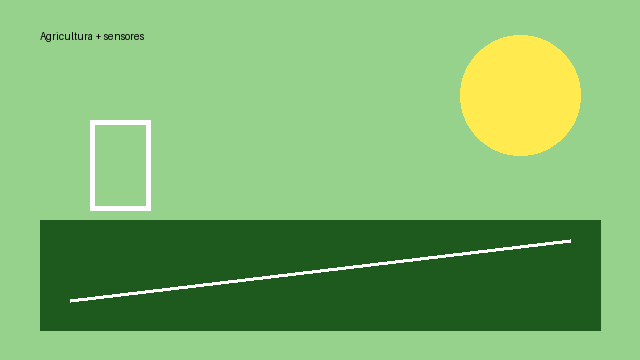


=== Imagen → Imagen ===
Aviso: Atlas Vector Search falló. Se usa búsqueda local exacta para demo.
Motivo: Invalid $project :: caused by :: Cannot do inclusion on field type in exclusion projection, full error: {'ok': 0.0, 'errmsg': 'Invalid $project :: caused by :: Cannot do inclusion on field type in exclusion projection', 'code': 31253, 'codeName': 'Lo


,img_id,descripcion,score,local_path
0,IMG001,Ilustración sintética de un campo agrícola con sensores y monitoreo tecnológico.,1.00000,/content/demo_multimodal_images/agricultura_sensores.png
1,IMG002,"Ilustración sintética de turismo rural con montañas, camino y paisaje natural.",0.94561,/content/demo_multimodal_images/turismo_rural.png
2,IMG003,Ilustración sintética de paneles solares y energía limpia en comunidad rural.,0.88587,/content/demo_multimodal_images/energia_solar.png


IMG001 | score=1.0000 | Ilustración sintética de un campo agrícola con sensores y monitoreo tecnológico.


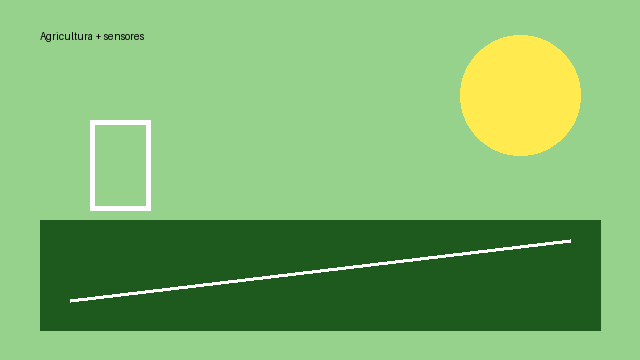

IMG002 | score=0.9456 | Ilustración sintética de turismo rural con montañas, camino y paisaje natural.


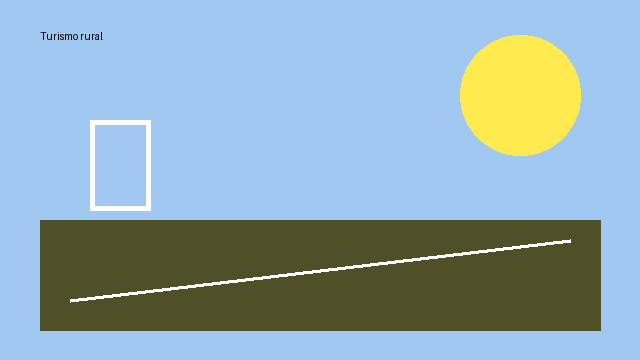

IMG003 | score=0.8859 | Ilustración sintética de paneles solares y energía limpia en comunidad rural.


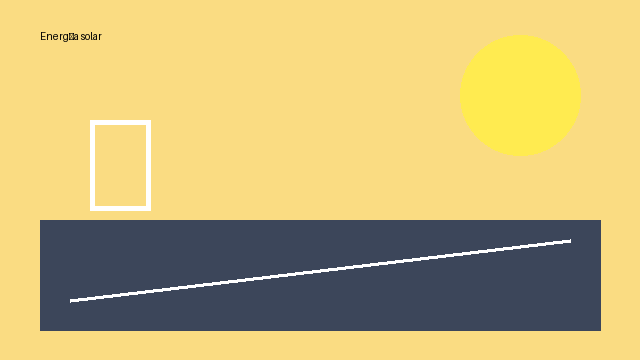


=== Imagen → Texto ===
Aviso: Atlas Vector Search falló. Se usa búsqueda local exacta para demo.
Motivo: Invalid $project :: caused by :: Cannot do inclusion on field type in exclusion projection, full error: {'ok': 0.0, 'errmsg': 'Invalid $project :: caused by :: Cannot do inclusion on field type in exclusion projection', 'code': 31253, 'codeName': 'Lo


,chunk_id,doc_id,type,contenido_texto,created_at,fuente,idioma,titulo,score
0,1,DOC003,text,"La energía solar permite a comunidades rurales acceder a electricidad limpia mediante paneles fotovoltaicos, almacen...",2026-04-30 16:22:18.768,demo,es,Energía solar en comunidades,0.236606
1,1,DOC001,text,"La agricultura de precisión utiliza sensores, datos satelitales e inteligencia artificial para monitorear cultivos, ...",2026-04-30 16:22:18.164,demo,es,Agricultura de precisión y sensores,0.217179
2,1,DOC002,text,"El turismo rural sostenible promueve experiencias culturales, paisajes naturales y participación comunitaria, reduci...",2026-04-30 16:22:18.518,demo,es,Turismo rural sostenible,0.203633


In [ ]:
query_image = SAMPLE_IMAGES[0]["local_path"]
print("Imagen consulta:")
display(Image.open(query_image).convert("RGB"))

print("\n=== Imagen → Imagen ===")
res_ii = search_image_to_image(query_image, top_k=3)
display(res_ii[[c for c in ["img_id", "descripcion", "score", "local_path"] if c in res_ii.columns]])
show_image_results(res_ii)

print("\n=== Imagen → Texto ===")
res_it = search_image_to_text(query_image, top_k=3)
display(res_it)

## 19. Verificación de persistencia

Este bloque muestra las consultas y respuestas guardadas.

In [ ]:
print("Consultas guardadas:", queries_collection.count_documents({}))
print("Respuestas guardadas:", answers_collection.count_documents({}))

recent = list(answers_collection.find({}, {"_id": 0}).sort("created_at", -1).limit(3))
pd.DataFrame(recent)

Consultas guardadas: 1
Respuestas guardadas: 1


,query_id,tipo_consulta,texto_pregunta,imagen_origen,answer,retrieved_text,retrieved_images,created_at,model
0,69f3821b68f898404f808cc5,text_to_text_and_image,¿Qué información hay sobre sensores y agricultura? Incluye imágenes relacionadas si existen.,None,"La información disponible sobre sensores y agricultura se encuentra en el texto ""Agricultura de precisión y sensores...","[{'type': 'text', 'doc_id': 'DOC001', 'chunk_id': 1, 'contenido_texto': 'La agricultura de precisión utiliza sensore...","[{'type': 'image', 'img_id': 'IMG001', 'created_at': 2026-04-30 16:22:19.171000, 'descripcion': 'Ilustración sintéti...",2026-04-30 16:23:55.882,llama-3.3-70b-versatile


## 20. Cierre conceptual

Este notebook demuestra que MongoDB Atlas puede funcionar como una base documental y vectorial para datos multimodales. La idea central es que cada modalidad se representa mediante embeddings:

- MiniLM para texto → texto.
- CLIP para texto ↔ imagen e imagen ↔ texto.

El flujo completo es:

```text
texto / imagen
    ↓
embedding
    ↓
Atlas Vector Search
    ↓
top-k resultados
    ↓
contexto multimodal
    ↓
LLM opcional
```